In [24]:
!pip install openai
import os
import base64
import json
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from openai import OpenAI

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)


In [25]:
train_dir = r"C:\Users\DELL\Downloads\annotations\train"   # contains 'mature' and 'regenerated' subfolders
test_dir  = r"C:\Users\DELL\Downloads\annotations\test"     # flat folder of test images
gt_dir    = r"C:\Users\DELL\Downloads\annotations\gt"  # contains 'mature' and 'regenerated' subfolders with same filenames as test_dir
kfold_dir = r"C:\Users\DELL\Downloads\annotations\Image_02\kfold"    # contains 'mature' and 'regenerated' subfolders; full pool of images for K-Fold CV


In [26]:
def get_train_data(root_directory):
    """Collects (image_path, label) pairs from train_dir/mature and train_dir/regenerated."""
    image_label_pairs = []
    for label in ["mature", "regenerated"]:
        label_dir = os.path.join(root_directory, label)
        if os.path.isdir(label_dir):
            for image_file in os.listdir(label_dir):
                image_path = os.path.join(label_dir, image_file)
                if os.path.isfile(image_path):
                    image_label_pairs.append((image_path, label))
    return image_label_pairs


def get_test_data(root_directory):
    """Collects all image paths from a flat test directory (no labels)."""
    image_paths = []
    for image_file in os.listdir(root_directory):
        image_path = os.path.join(root_directory, image_file)
        if os.path.isfile(image_path):
            image_paths.append(image_path)
    return image_paths


In [27]:
train_df = pd.DataFrame(get_train_data(train_dir), columns=['image path', 'label'])
train_df


,image path,label
0,C:\Users\DELL\Downloads\annotations\train\matu...,mature
1,C:\Users\DELL\Downloads\annotations\train\matu...,mature
2,C:\Users\DELL\Downloads\annotations\train\matu...,mature
3,C:\Users\DELL\Downloads\annotations\train\matu...,mature
4,C:\Users\DELL\Downloads\annotations\train\matu...,mature
5,C:\Users\DELL\Downloads\annotations\train\matu...,mature
6,C:\Users\DELL\Downloads\annotations\train\matu...,mature
7,C:\Users\DELL\Downloads\annotations\train\matu...,mature
8,C:\Users\DELL\Downloads\annotations\train\matu...,mature
9,C:\Users\DELL\Downloads\annotations\train\matu...,mature


In [28]:
test_df = pd.DataFrame(get_test_data(test_dir), columns=['image path'])
test_df


,image path
0,C:\Users\DELL\Downloads\annotations\test\10_1.png
1,C:\Users\DELL\Downloads\annotations\test\11_1.png
2,C:\Users\DELL\Downloads\annotations\test\12_1.png
3,C:\Users\DELL\Downloads\annotations\test\181.png
4,C:\Users\DELL\Downloads\annotations\test\182.png
5,C:\Users\DELL\Downloads\annotations\test\183.png
6,C:\Users\DELL\Downloads\annotations\test\184.png
7,C:\Users\DELL\Downloads\annotations\test\185.png
8,C:\Users\DELL\Downloads\annotations\test\186.png
9,C:\Users\DELL\Downloads\annotations\test\188.png


In [29]:
# Load the full labeled pool used for K-Fold Cross-Validation (separate from train_dir)
kfold_df = pd.DataFrame(get_train_data(kfold_dir), columns=['image path', 'label'])
kfold_df


,image path,label
0,C:\Users\DELL\Downloads\annotations\Image_02\k...,mature
1,C:\Users\DELL\Downloads\annotations\Image_02\k...,mature
2,C:\Users\DELL\Downloads\annotations\Image_02\k...,mature
3,C:\Users\DELL\Downloads\annotations\Image_02\k...,mature
4,C:\Users\DELL\Downloads\annotations\Image_02\k...,mature
...,...,...
56,C:\Users\DELL\Downloads\annotations\Image_02\k...,regenerated
57,C:\Users\DELL\Downloads\annotations\Image_02\k...,regenerated
58,C:\Users\DELL\Downloads\annotations\Image_02\k...,regenerated
59,C:\Users\DELL\Downloads\annotations\Image_02\k...,regenerated


In [30]:
def get_ground_truth_labels(gt_directory):
    """Builds a {filename: label} lookup from gt_dir/mature and gt_dir/regenerated."""
    gt_lookup = {}
    for label in ["mature", "regenerated"]:
        label_dir = os.path.join(gt_directory, label)
        if os.path.isdir(label_dir):
            for image_file in os.listdir(label_dir):
                if os.path.isfile(os.path.join(label_dir, image_file)):
                    gt_lookup[image_file] = label
    return gt_lookup


gt_lookup = get_ground_truth_labels(gt_dir)

# Match each test image's filename against the ground-truth lookup
test_df["label"] = test_df["image path"].apply(
    lambda p: gt_lookup.get(os.path.basename(p), "unknown")
)

# Flag any test images with no matching ground-truth file
unmatched = test_df[test_df["label"] == "unknown"]["image path"].tolist()
if unmatched:
    print("Warning: no ground-truth match found for:", unmatched)

test_df


,image path,label
0,C:\Users\DELL\Downloads\annotations\test\10_1.png,mature
1,C:\Users\DELL\Downloads\annotations\test\11_1.png,mature
2,C:\Users\DELL\Downloads\annotations\test\12_1.png,mature
3,C:\Users\DELL\Downloads\annotations\test\181.png,regenerated
4,C:\Users\DELL\Downloads\annotations\test\182.png,regenerated
5,C:\Users\DELL\Downloads\annotations\test\183.png,regenerated
6,C:\Users\DELL\Downloads\annotations\test\184.png,regenerated
7,C:\Users\DELL\Downloads\annotations\test\185.png,regenerated
8,C:\Users\DELL\Downloads\annotations\test\186.png,regenerated
9,C:\Users\DELL\Downloads\annotations\test\188.png,regenerated


In [31]:
def to_base64(path):
    with open(path, 'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


class Processor:
    def __init__(self, mature_image_list, regenerated_image_list, max_size, test_image_path):
        self.mature_image_list = mature_image_list
        self.regenerated_image_list = regenerated_image_list
        self.max_size = max_size
        self.test_image = test_image_path
        self.messages = None

    def get_image_data(self, img_path):
        return self.resize_and_convert_to_base64(img_path)

    def resize_and_convert_to_base64(self, image_path):
        size = self.max_size
        with Image.open(image_path) as img:
            width, height = img.size
            if width > size or height > size:
                if width > height:
                    new_width = size
                    new_height = int((size / width) * height)
                else:
                    new_height = size
                    new_width = int((size / height) * width)
                img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

            buffered = BytesIO()
            img.save(buffered, format="PNG")
            return base64.b64encode(buffered.getvalue()).decode("utf-8")

    def get_content(self):
        content_list = [{
            "type": "text",
            "text": (
                'Here are some images of axons and their respective classes. '
                'Please act as an image classifier and classify the last image as either '
                '"mature" or "regenerated" in the given format. '
                'Respond only with either "mature" or "regenerated". '
                'Do not write any explanations, comments, or plain text.'
            )
        }]

        for img_path in self.mature_image_list:
            content_list.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpg;base64,{self.get_image_data(img_path)}"}
            })
            content_list.append({"type": "text", "text": "mature"})

        for img_path in self.regenerated_image_list:
            content_list.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpg;base64,{self.get_image_data(img_path)}"}
            })
            content_list.append({"type": "text", "text": "regenerated"})

        return content_list

    def get_message(self):
        self.messages = [
            {"role": "user", "content": self.get_content()},
            {"role": "user", "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpg;base64,{self.get_image_data(self.test_image)}"}
                }
            ]}
        ]


In [32]:
client = OpenAI(api_key="api_key"
def predict(mature_image_list, regenerated_image_list, max_size, test_image_path):
    image_processor = Processor(
        mature_image_list=mature_image_list,
        regenerated_image_list=regenerated_image_list,
        max_size=max_size,
        test_image_path=test_image_path
    )

    image_processor.get_message()
    messages = image_processor.messages

    response = client.chat.completions.create(
        model='gpt-4o-2024-11-20',
        messages=messages,
        temperature=0.0,
        max_tokens=200
    )

    return response.choices[0].message.content.strip().lower()


In [33]:
max_size = 200

results = {}

mature_img_list = train_df[train_df["label"] == "mature"]["image path"].tolist()
regenerated_img_list = train_df[train_df["label"] == "regenerated"]["image path"].tolist()

for idx in tqdm(test_df.index):
    query_image_path = test_df["image path"][idx]
    expectation = test_df["label"][idx]
    test_image_name = os.path.basename(query_image_path)

    prediction = predict(
        mature_image_list=mature_img_list,
        regenerated_image_list=regenerated_img_list,
        max_size=max_size,
        test_image_path=query_image_path
    )

    results[test_image_name] = {
        "query_image_path": query_image_path,
        "expectation": expectation,
        "prediction": prediction
    }

# Save results
with open("Results.json", "w") as outfile:
    json.dump(results, outfile, indent=2)

print("Done. Results saved to Results.json")


100%|██████████| 23/23 [08:00<00:00, 20.88s/it]

Done. Results saved to Results.json


In [34]:
with open("Results.json", "r") as f:
    results = json.load(f)

results


{'10_1.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\10_1.png',
  'expectation': 'mature',
  'prediction': 'mature'},
 '11_1.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\11_1.png',
  'expectation': 'mature',
  'prediction': 'regenerated'},
 '12_1.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\12_1.png',
  'expectation': 'mature',
  'prediction': 'regenerated'},
 '181.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\181.png',
  'expectation': 'regenerated',
  'prediction': 'regenerated'},
 '182.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\182.png',
  'expectation': 'regenerated',
  'prediction': 'regenerated'},
 '183.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\183.png',
  'expectation': 'regenerated',
  'prediction': 'regenerated'},
 '184.png': {'query_image_path': 'C:\\Users\\DELL\\Downloads\\annotations\\test\\184

Accuracy:  0.74
Precision: 1.00
Recall:    0.50
F1 Score:  0.67


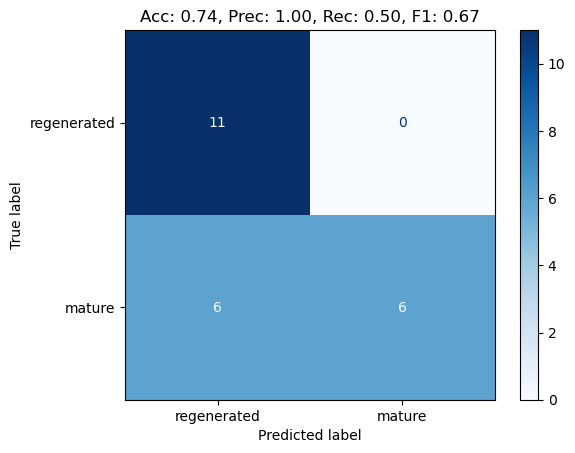

In [35]:
# Define class mapping
class_mapping = {"regenerated": 0, "mature": 1}

actual = []
prediction = []
unknown_classes = []

for img, data in results.items():
    actual_class = data["expectation"]
    pred_class = data["prediction"]

    if pred_class not in class_mapping or actual_class not in class_mapping:
        unknown_classes.append((img, actual_class, pred_class))
        print(f"Skipping {img}: expectation='{actual_class}', prediction='{pred_class}'")
        continue

    actual.append(class_mapping[actual_class])
    prediction.append(class_mapping[pred_class])

# Compute metrics
accuracy = accuracy_score(actual, prediction)
precision = precision_score(actual, prediction, average='binary', pos_label=class_mapping["mature"], zero_division=0)
recall = recall_score(actual, prediction, average='binary', pos_label=class_mapping["mature"], zero_division=0)
f1 = f1_score(actual, prediction, average='binary', pos_label=class_mapping["mature"], zero_division=0)

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

if unknown_classes:
    print("\nUnknown / unmapped predictions:")
    for u in unknown_classes:
        print(u)

# Confusion matrix
matrix = confusion_matrix(actual, prediction, labels=list(class_mapping.values()))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=list(class_mapping.keys()))
cm_display.plot(cmap=plt.cm.Blues)
plt.title(f"Acc: {accuracy:.2f}, Prec: {precision:.2f}, Rec: {recall:.2f}, F1: {f1:.2f}")
plt.show()


In [36]:
rows = []
for img, data in results.items():
    rows.append({
        "image": img,
        "expectation": data["expectation"],
        "prediction": data["prediction"],
        "correct": data["expectation"] == data["prediction"]
    })

results_df = pd.DataFrame(rows)
results_df


,image,expectation,prediction,correct
0,10_1.png,mature,mature,True
1,11_1.png,mature,regenerated,False
2,12_1.png,mature,regenerated,False
3,181.png,regenerated,regenerated,True
4,182.png,regenerated,regenerated,True
5,183.png,regenerated,regenerated,True
6,184.png,regenerated,regenerated,True
7,185.png,regenerated,regenerated,True
8,186.png,regenerated,regenerated,True
9,188.png,regenerated,regenerated,True


In [37]:
from sklearn.model_selection import StratifiedKFold

print("=== Starting K-Fold Cross-Validation ===")

K = 5
print(f"Pooling all images from kfold_dir (mature + regenerated): {len(kfold_df)} images total")

pool_paths = kfold_df["image path"].tolist()
pool_labels = kfold_df["label"].tolist()

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

kfold_results = {}   # fold_index -> list of {image, expectation, prediction}
fold_assignments = list(skf.split(pool_paths, pool_labels))

print(f"Created {K} stratified folds.\n")
for fold_idx, (context_idx, query_idx) in enumerate(fold_assignments):
    print(f"Fold {fold_idx + 1}/{K}: {len(query_idx)} query images, {len(context_idx)} context images")


=== Starting K-Fold Cross-Validation ===
Pooling all images from kfold_dir (mature + regenerated): 61 images total
Created 5 stratified folds.

Fold 1/5: 13 query images, 48 context images
Fold 2/5: 12 query images, 49 context images
Fold 3/5: 12 query images, 49 context images
Fold 4/5: 12 query images, 49 context images
Fold 5/5: 12 query images, 49 context images


In [39]:
import random

# Number of support (few-shot) images per class shown to GPT-4o for each query.
# Lower this further if you still hit rate limits (e.g. set to 1).
support_per_class = 3

random.seed(42)  # reproducible random subsampling

for fold_idx, (context_idx, query_idx) in enumerate(fold_assignments):
    print(f"\n=== Fold {fold_idx + 1}/{K} ===")

    context_paths = [pool_paths[i] for i in context_idx]
    context_labels = [pool_labels[i] for i in context_idx]

    fold_mature_pool = [p for p, l in zip(context_paths, context_labels) if l == "mature"]
    fold_regenerated_pool = [p for p, l in zip(context_paths, context_labels) if l == "regenerated"]

    print(f"Available context pool: {len(fold_mature_pool)} mature, {len(fold_regenerated_pool)} regenerated")

    fold_records = []
    for q in query_idx:
        query_path = pool_paths[q]
        expectation = pool_labels[q]
        query_name = os.path.basename(query_path)

        # Randomly subsample a smaller support set for this specific query
        # to keep the request within the API's tokens-per-minute limit.
        n_mature = min(support_per_class, len(fold_mature_pool))
        n_regenerated = min(support_per_class, len(fold_regenerated_pool))
        sampled_mature_list = random.sample(fold_mature_pool, n_mature)
        sampled_regenerated_list = random.sample(fold_regenerated_pool, n_regenerated)

        print(f"  Classifying {query_name} (true label: {expectation}) "
              f"using {n_mature} mature + {n_regenerated} regenerated support images ...")

        prediction = predict(
            mature_image_list=sampled_mature_list,
            regenerated_image_list=sampled_regenerated_list,
            max_size=max_size,
            test_image_path=query_path
        )

        print(f"    -> Predicted: {prediction}")

        fold_records.append({
            "image": query_name,
            "expectation": expectation,
            "prediction": prediction
        })

    kfold_results[fold_idx] = fold_records

# Save K-Fold results
with open("KFold_Results.json", "w") as outfile:
    json.dump(kfold_results, outfile, indent=2)

print("\n=== K-Fold Cross-Validation complete. Results saved to KFold_Results.json ===")



=== Fold 1/5 ===
Available context pool: 19 mature, 29 regenerated
  Classifying 12_1.png (true label: mature) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 17_4.png (true label: mature) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 1_1.png (true label: mature) using 3 mature + 3 regenerated support images ...
    -> Predicted: mature
  Classifying 22_4.png (true label: mature) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 23_4.png (true label: mature) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 10.png (true label: regenerated) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 139.png (true label: regenerated) using 3 mature + 3 regenerated support images ...
    -> Predicted: regenerated
  Classifying 141.png (true label: regenerated) using 3 mature 

In [40]:
class_mapping = {"regenerated": 0, "mature": 1}

fold_metrics = []
all_actual = []
all_predicted = []

print("=== Per-Fold Metrics ===\n")
for fold_idx, records in kfold_results.items():
    fold_actual = []
    fold_pred = []

    for r in records:
        if r["expectation"] in class_mapping and r["prediction"] in class_mapping:
            fold_actual.append(class_mapping[r["expectation"]])
            fold_pred.append(class_mapping[r["prediction"]])
        else:
            print(f"Fold {fold_idx + 1}: skipping unmapped prediction for {r['image']} "
                  f"(expectation='{r['expectation']}', prediction='{r['prediction']}')")

    acc = accuracy_score(fold_actual, fold_pred)
    prec = precision_score(fold_actual, fold_pred, average='binary', pos_label=1, zero_division=0)
    rec = recall_score(fold_actual, fold_pred, average='binary', pos_label=1, zero_division=0)
    f1 = f1_score(fold_actual, fold_pred, average='binary', pos_label=1, zero_division=0)

    print(f"Fold {fold_idx + 1}: Accuracy={acc:.2f}, Precision={prec:.2f}, Recall={rec:.2f}, F1={f1:.2f}")

    fold_metrics.append({
        "fold": fold_idx + 1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

    all_actual.extend(fold_actual)
    all_predicted.extend(fold_pred)

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df


=== Per-Fold Metrics ===

Fold 1: Accuracy=0.62, Precision=0.50, Recall=0.20, F1=0.29
Fold 2: Accuracy=0.83, Precision=1.00, Recall=0.60, F1=0.75
Fold 3: Accuracy=0.58, Precision=0.00, Recall=0.00, F1=0.00
Fold 4: Accuracy=0.67, Precision=1.00, Recall=0.20, F1=0.33
Fold 5: Accuracy=0.83, Precision=1.00, Recall=0.50, F1=0.67


,fold,accuracy,precision,recall,f1
0,1,0.615385,0.5,0.2,0.285714
1,2,0.833333,1.0,0.6,0.750000
2,3,0.583333,0.0,0.0,0.000000
3,4,0.666667,1.0,0.2,0.333333
4,5,0.833333,1.0,0.5,0.666667


=== Overall K-Fold Metrics (pooled across all folds) ===
Accuracy:  0.70
Precision: 0.88
Recall:    0.29
F1 Score:  0.44

=== Mean +/- Std across folds ===
Accuracy:  0.71 +/- 0.12
Precision: 0.70 +/- 0.45
Recall:    0.30 +/- 0.24
F1 Score:  0.41 +/- 0.30


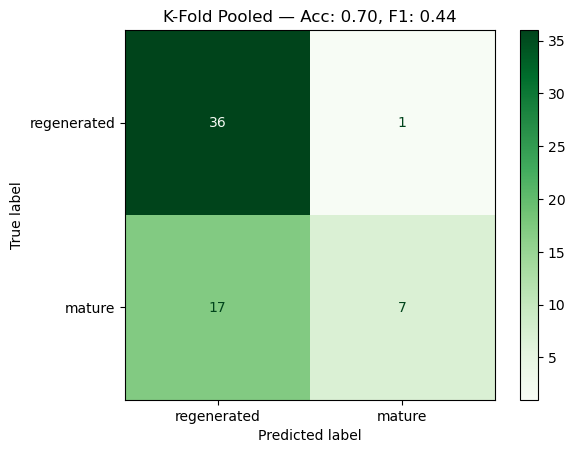

In [41]:
overall_accuracy = accuracy_score(all_actual, all_predicted)
overall_precision = precision_score(all_actual, all_predicted, average='binary', pos_label=1, zero_division=0)
overall_recall = recall_score(all_actual, all_predicted, average='binary', pos_label=1, zero_division=0)
overall_f1 = f1_score(all_actual, all_predicted, average='binary', pos_label=1, zero_division=0)

print("=== Overall K-Fold Metrics (pooled across all folds) ===")
print(f"Accuracy:  {overall_accuracy:.2f}")
print(f"Precision: {overall_precision:.2f}")
print(f"Recall:    {overall_recall:.2f}")
print(f"F1 Score:  {overall_f1:.2f}")

print("\n=== Mean +/- Std across folds ===")
print(f"Accuracy:  {fold_metrics_df['accuracy'].mean():.2f} +/- {fold_metrics_df['accuracy'].std():.2f}")
print(f"Precision: {fold_metrics_df['precision'].mean():.2f} +/- {fold_metrics_df['precision'].std():.2f}")
print(f"Recall:    {fold_metrics_df['recall'].mean():.2f} +/- {fold_metrics_df['recall'].std():.2f}")
print(f"F1 Score:  {fold_metrics_df['f1'].mean():.2f} +/- {fold_metrics_df['f1'].std():.2f}")

# Overall confusion matrix (pooled)
overall_matrix = confusion_matrix(all_actual, all_predicted, labels=[0, 1])
cm_display = ConfusionMatrixDisplay(confusion_matrix=overall_matrix, display_labels=["regenerated", "mature"])
cm_display.plot(cmap=plt.cm.Greens)
plt.title(f"K-Fold Pooled — Acc: {overall_accuracy:.2f}, F1: {overall_f1:.2f}")
plt.show()


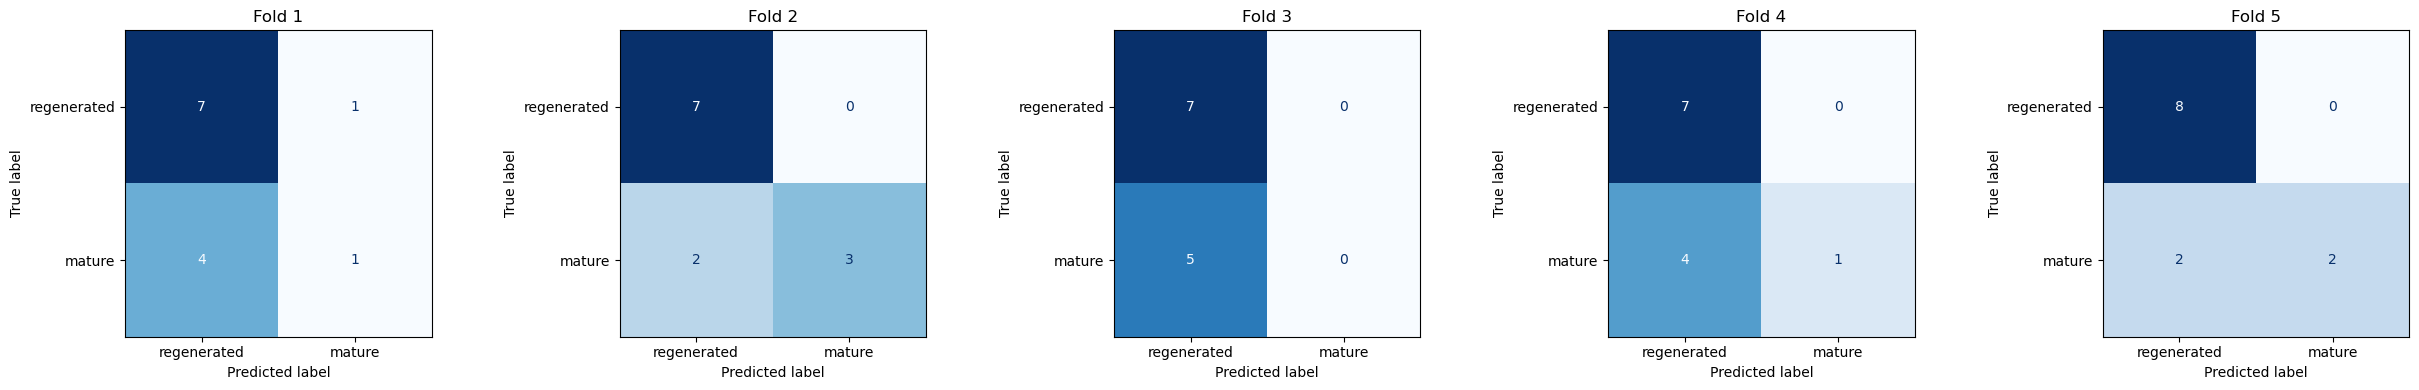

In [42]:
fig, axes = plt.subplots(1, K, figsize=(5 * K, 4))

for fold_idx, records in kfold_results.items():
    fold_actual = []
    fold_pred = []
    for r in records:
        if r["expectation"] in class_mapping and r["prediction"] in class_mapping:
            fold_actual.append(class_mapping[r["expectation"]])
            fold_pred.append(class_mapping[r["prediction"]])

    matrix = confusion_matrix(fold_actual, fold_pred, labels=[0, 1])
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["regenerated", "mature"])
    cm_display.plot(ax=axes[fold_idx], cmap=plt.cm.Blues, colorbar=False)
    axes[fold_idx].set_title(f"Fold {fold_idx + 1}")

plt.tight_layout()
plt.show()


In [43]:
print("kfold_dir set to:", kfold_dir)
print()
print("Does kfold_dir exist?", os.path.isdir(kfold_dir))
print("Contents of kfold_dir:", os.listdir(kfold_dir) if os.path.isdir(kfold_dir) else "N/A")
print()

mature_path = os.path.join(kfold_dir, "mature")
regenerated_path = os.path.join(kfold_dir, "regenerated")

print("mature_path:", mature_path)
print("Does mature folder exist?", os.path.isdir(mature_path))
if os.path.isdir(mature_path):
    print("Files in mature:", os.listdir(mature_path))
print()

print("regenerated_path:", regenerated_path)
print("Does regenerated folder exist?", os.path.isdir(regenerated_path))
if os.path.isdir(regenerated_path):
    print("Files in regenerated:", os.listdir(regenerated_path))
print()

print("kfold_df shape:", kfold_df.shape)
print("kfold_df label counts:")
print(kfold_df["label"].value_counts())

kfold_dir set to: C:\Users\DELL\Downloads\annotations\Image_02\kfold

Does kfold_dir exist? True
Contents of kfold_dir: ['mature', 'regenerated']

mature_path: C:\Users\DELL\Downloads\annotations\Image_02\kfold\mature
Does mature folder exist? True
Files in mature: ['10_1.png', '11_1.png', '12_1.png', '13_1.png', '14_4.png', '15_4.png', '16_4.png', '17_4.png', '18_4.png', '19_4.png', '1_1.png', '20_4.png', '21_4.png', '22_4.png', '23_4.png', '24_4.png', '2_1.png', '3_1.png', '4_1.png', '5_1.png', '6_1.png', '7_1.png', '8_1.png', '9_1.png']

regenerated_path: C:\Users\DELL\Downloads\annotations\Image_02\kfold\regenerated
Does regenerated folder exist? True
Files in regenerated: ['1.png', '10.png', '139.png', '140.png', '141.png', '142.png', '143.png', '146.png', '147.png', '148.png', '149.png', '150.png', '151.png', '153.png', '154.png', '155.png', '156.png', '157.png', '158.png', '159.png', '160.png', '181.png', '182.png', '183.png', '184.png', '185.png', '186.png', '188.png', '189.png

In [ ]:
for sub in os.listdir(regenerated_path):
    full = os.path.join(regenerated_path, sub)
    print(sub, "-> is dir:", os.path.isdir(full), "| is file:", os.path.isfile(full))
    if os.path.isdir(full):
        print("   contents:", os.listdir(full))